In [1]:
from bunch import bunchify
from scipy import stats

import httplib2 as http
import json
import numpy as np
import matplotlib.pyplot as plt

BASE_URL = "http://localhost:18000"

def get_test_runs():
    h = http.Http()
    url = BASE_URL + "/json/ctsresult"
    print "Requesting:", url
    response, content = h.request(url, "GET")
    return [bunchify(x) for x in json.loads(content)]

def get_test_run_details(run_id):
    h = http.Http()
    url = BASE_URL + "/json/ctsresult/" + run_id
    print "Requesting:", url
    response, content = h.request(url, "GET")
    return bunchify(json.loads(content))

def get_test_results(test_run_id, device_id, device_version):
    h = http.Http()
#     TODO: change retrieval by device and version
#     url = "%s/json/ctsresult/%s/%s" % (BASE_URL, test_run_id, "%s_%s" %(device_id, device_version))
    url = "%s/json/ctsresult/%s/%s" % (BASE_URL, test_run_id, device_id)
    print "Requesting:", url
    response, content = h.request(url, "GET")
    return bunchify(json.loads(content))

def get_device_info(test_run, device_id, version_id):
    dev_info = [x for x in test_run.devices if (x.id == device_id) and (x.versionID == version_id)][0]
    return dev_info

class StatsContainer(object):
    def __init__(self):
        self.combined = []
        self.pixel = []
        self.percent = []
        self.maxRGBA = []

    def add(self, closest):
        self.combined.append(closest.diffs.combined)
        self.pixel.append(closest.diffs.pixel)
        self.percent.append(closest.diffs.percent)
        self.maxRGBA.extend(closest.maxRGBADiffs)

def print_pass_fails(dev_info, tests, failFn, details=True, quiet=False):
    statsObj = StatsContainer()
    failedTests = set()

    passCount = 0
    noDiffs = 0
    for oneTest in tests:
        # Ignore tests for which we have not results.
        if len(oneTest.diffs) == 0:
            if details:
                print ".  %s  ...........    FAIL (no closests)" % oneTest.name
            noDiffs += 1
            continue

        # Account for pass and fails
        testPasses = not failFn(oneTest)
        best =  oneTest.diffs[oneTest.closestDiffIdx]
        if (not testPasses and not quiet) or details:
            print "o  %s  ...........    %s             %f %f %f  %s" % (oneTest.name, "PASS" if testPasses else "FAIL", best.diffs.combined, best.diffs.percent, best.diffs.pixel, best.maxRGBADiffs)
        if testPasses:
            passCount += 1
        elif best:
            statsObj.add(best)
            failedTests.add(oneTest.name)
    print "Device %s(%s)/%s: Total: %d  Pass: %d   Fail: %d    No diffs: %d" % (
        dev_info.name,
        dev_info.id,
        dev_info.versionID,
        len(tests),
        passCount,
        len(tests)-noDiffs-passCount,
        noDiffs)
    return statsObj, failedTests

def show_boxplot(statsObj):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 12))
    ret1 = axes[0, 0].boxplot(statsObj.combined, labels=["combined1"])
    ret2 = axes[0, 1].boxplot(statsObj.pixel, labels=["pixel"])
    ret3 = axes[1, 0].boxplot(statsObj.percent, labels=["percent"])
    ret4 = axes[1, 1].boxplot(statsObj.maxRGBA, labels=["maxRGBA"])

def get_threshold_fail_fn(maxCombined, maxPixel, maxPercent, maxRGBA):
    def threshold_fn(oneTest):
        if len(oneTest.diffs) == 0:
            return True
        closest = oneTest.diffs[oneTest.closestDiffIdx]
        ret = ((closest.diffs.combined > maxCombined) or
                (closest.diffs.pixel > maxPixel) or
                (closest.diffs.percent > maxPercent) or
                (max(closest.maxRGBADiffs) > maxRGBA))
        # print ret, "  :  ", closest.diffs.combined, maxCombined, closest.diffs.pixel, maxPixel, closest.diffs.percent, maxPercent, max(closest.maxRGBADiffs), maxRGBA
        return ret
    return threshold_fn

In [5]:
# Fetch the target data.
test_runs = get_test_runs()
targetRunID = "testrun-1507554105762"
test_run = [x for x in test_runs if x.id == targetRunID][0]
test_run = get_test_run_details(test_run.id)
print "Target test run retrieved."

ref_dev_id = "sailfish"
ref_dev_version = "26"
dev_info = get_device_info(test_run, ref_dev_id, ref_dev_version)
tests_ref_dev = get_test_results(test_run.id, ref_dev_id, ref_dev_version)
print "Test results loaded for ref device"

absoluteFailFn = lambda oneTest: (len(oneTest.diffs) == 0) or (oneTest.diffs[oneTest.closestDiffIdx].diffs.combined > 0)
statsObj, _ = print_pass_fails(dev_info, tests_ref_dev, absoluteFailFn)

Requesting: http://localhost:18000/json/ctsresult
Requesting: http://localhost:18000/json/ctsresult/testrun-1507554105762
Target test run retrieved.
Requesting: http://localhost:18000/json/ctsresult/testrun-1507554105762/sailfish
Test results loaded for ref device
o  3x3bitmaprect  ...........    PASS             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  BlurDrawImage  ...........    FAIL             4.300056 29.821777 19544.000000  [136, 251, 136, 0]
o  CubicStroke  ...........    PASS             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  OverStroke  ...........    FAIL             1.732031 9.920000 24800.000000  [87, 93, 87, 0]
o  PlusMergesAA  ...........    PASS             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aaclip  ...........    PASS             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aarectmodes  ...........    PASS             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aaxfermodes  ...........    FAIL             0.680253 0.742764 4568.000000  [165, 192, 192, 

In [6]:
%matplotlib inline

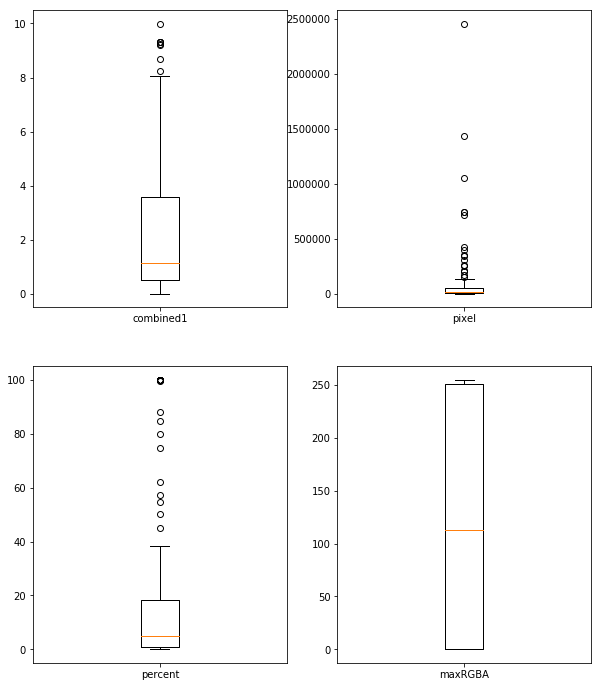

In [7]:
show_boxplot(statsObj)

Choose the following thresholds for other tests to passe based on graphs above

In [8]:
maxCombined = 2.6
maxPixel = 100000
maxPercent = 10.0
maxRGBA = 255

th_fail_fn = get_threshold_fail_fn(maxCombined, maxPixel, maxPercent, maxRGBA)
allFailedTests = []
print "-" * 80
for dev_info in test_run.devices:
    _, failedTests = print_pass_fails(dev_info, tests_ref_dev, th_fail_fn, details=False, quiet=True)
    allFailedTests.append(failedTests)
    print "-" * 80

unionOfFailedTests = reduce(lambda a,b: a | b, allFailedTests, set())
intersectOfFailedTests = reduce(lambda a,b: a & b, allFailedTests, unionOfFailedTests)

print "Union    : (%d) " % len(unionOfFailedTests)
print "Intersect: (%d) " % len(intersectOfFailedTests)
print "Details:"

unionOfFailedTests = list(unionOfFailedTests)
unionOfFailedTests.sort()
for oneTest in unionOfFailedTests:
    print '"%s",' % oneTest


--------------------------------------------------------------------------------
Device Xperia Z2(D6503)/21: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------------------------------------------------
Device Xperia Z3(D6603)/21: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------------------------------------------------
Device Xperia Z5 Compact(E5803)/22: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------------------------------------------------
Device Sony Xperia X(F5121)/23: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------------------------------------------------
Device Huawei Mate 9(HWMHA)/24: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------------------------------------------------
Device SH-04H(SH-04H)/23: Total: 611  Pass: 544   Fail: 55    No diffs: 12
--------------------------------------